In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


In [36]:
from param import get_baseline_params, full_param_name_list
from sswm import SM_C_H
from growth_num import CropDevelopmentSSWM


Simulation Setting

In [37]:

N_YEARS  = 50
LAI_REF  = 6
RF_ALPHA = 0.01
EO       = 0.0035

AI_SCENARIOS = {
    'AI = 0.6': 0.6,
    'AI = 0.9': 0.9,
    'AI = 1.0': 1.0,
    'AI = 1.2': 1.2,
}

THINNING = {
    'Unthinned':           0.00,
    'Low (20%)':           0.20,
    'Moderate-low (30%)':  0.30,
    'Moderate (40%)':      0.40,
    'Moderate-high (50%)': 0.50,
    'High (60%)':          0.60,
}

COLORS = {
    'Unthinned':           'black',
    'Low (20%)':           '#1f77b4',
    'Moderate-low (30%)':  '#9edae5',
    'Moderate (40%)':      '#f1c40f',
    'Moderate-high (50%)': '#ff7f0e',
    'High (60%)':          '#d62728',
}

YEARS = np.arange(0, N_YEARS + 1)

Simulation Run

In [19]:
all_results = {}

for ai_label, AI in AI_SCENARIOS.items():
    rf_lambda = AI * EO / RF_ALPHA
    all_results[ai_label] = {}

    for scenario, reduction in THINNING.items():
        LAI  = LAI_REF * (1.0 - reduction)
        rows = []

        for year in YEARS:
            params = get_baseline_params(soil_i=3)
            params.update(Eo=EO, rf_alpha=RF_ALPHA, rf_lambda=rf_lambda, LAI=LAI)
            sm = SM_C_H([params[p] for p in full_param_name_list],
                        f_wilt=0.05, f_star=0.95)

            ET_mm   = sm.get_mean_et(sm.p0) * params['T_GS'] * 1000
            T_mm    = sm.get_mean_t(sm.p0)  * params['T_GS'] * 1000
            E_mm    = ET_mm - T_mm
            Tww_mm  = sm.T_ww  * sm.n * sm.Zm * params['T_GS'] * 1000
            Emax_mm = sm.E_max * sm.n * sm.Zm * params['T_GS'] * 1000
            I = (sm.rf_alpha - sm.rf / sm.rf_lambda) * sm.rf_lambda * params['T_GS'] * 1000
            
            gm = CropDevelopmentSSWM(
                sm_model=sm,
                g_plus=params['g_plus'], #0.0006
                a=params['a'],
                xi=sm.s_star,
                s_tilde=sm.s_wilt,
                b0=LAI,
                Tg=params['T_GS'],
            )
            mg = gm.mean_g()
            if ai_label == 'AI = 0.6' and scenario == 'High (60%)':
                print(f"yr={year:3d} LAI={LAI:.3f} mean_g={mg:.8f} dLAI={mg*params['T_GS']:.5f}")
            mean_g_annual = mg * params['T_GS'] 

            if mean_g_annual > 0:
                LAI_new = min(LAI + mean_g_annual, LAI_REF)
            else:
                mean_g_annual = 0.0
                LAI_new = LAI

            rows.append(dict(
                year=year,
                LAI=LAI,
                dLAI=mean_g_annual,
                ET=ET_mm,
                T=T_mm,
                E=E_mm,
                T_Eo=T_mm / (EO * params['T_GS'] * 1000) if np.isfinite(T_mm) else np.nan,
                Tww=Tww_mm,
                Emax=Emax_mm,
                I = I,
                
            ))

            LAI = LAI_new

        all_results[ai_label][scenario] = pd.DataFrame(rows)



yr=  0 LAI=2.400 mean_g=0.00041416 dLAI=0.07455
yr=  1 LAI=2.475 mean_g=0.00041124 dLAI=0.07402
yr=  2 LAI=2.549 mean_g=0.00040839 dLAI=0.07351
yr=  3 LAI=2.622 mean_g=0.00040561 dLAI=0.07301
yr=  4 LAI=2.695 mean_g=0.00040291 dLAI=0.07252
yr=  5 LAI=2.768 mean_g=0.00040028 dLAI=0.07205
yr=  6 LAI=2.840 mean_g=0.00039772 dLAI=0.07159
yr=  7 LAI=2.911 mean_g=0.00039523 dLAI=0.07114
yr=  8 LAI=2.982 mean_g=0.00039281 dLAI=0.07070
yr=  9 LAI=3.053 mean_g=0.00039044 dLAI=0.07028
yr= 10 LAI=3.123 mean_g=0.00038815 dLAI=0.06987
yr= 11 LAI=3.193 mean_g=0.00038591 dLAI=0.06946
yr= 12 LAI=3.263 mean_g=0.00038372 dLAI=0.06907
yr= 13 LAI=3.332 mean_g=0.00038160 dLAI=0.06869
yr= 14 LAI=3.400 mean_g=0.00037952 dLAI=0.06831
yr= 15 LAI=3.469 mean_g=0.00037750 dLAI=0.06795
yr= 16 LAI=3.537 mean_g=0.00037553 dLAI=0.06760
yr= 17 LAI=3.604 mean_g=0.00037360 dLAI=0.06725
yr= 18 LAI=3.672 mean_g=0.00037172 dLAI=0.06691
yr= 19 LAI=3.738 mean_g=0.00036989 dLAI=0.06658
yr= 20 LAI=3.805 mean_g=0.00036810 dLAI=

Plot: LAI increment 

<>:28: SyntaxWarning: invalid escape sequence '\c'
<>:28: SyntaxWarning: invalid escape sequence '\c'
/var/folders/ht/5gbx5w8s7bzgrtr54j536cnw0000gn/T/ipykernel_51778/4216775875.py:28: SyntaxWarning: invalid escape sequence '\c'
  color='grey', ls=':', lw=1.2, label='$g_+ \cdot T_{gs}$')


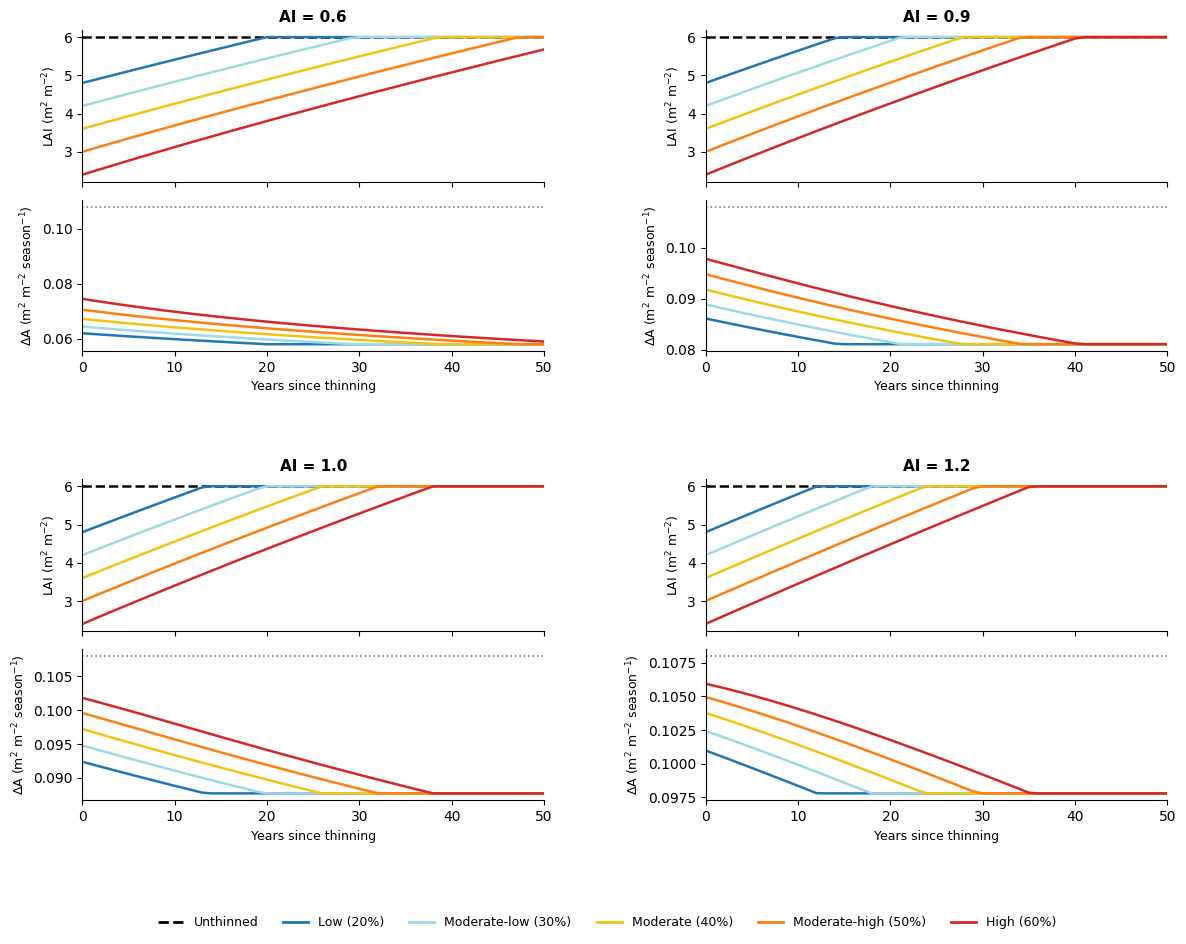

In [26]:
fig2 = plt.figure(figsize=(14, 10))
gs2  = GridSpec(2, 2, figure=fig2, hspace=0.4, wspace=0.35)

for i, (ai_label, AI) in enumerate(AI_SCENARIOS.items()):
    row = i // 2
    col = i % 2

    igs     = GridSpecFromSubplotSpec(2, 1,
                                      subplot_spec=gs2[row, col],
                                      hspace=0.12)
    ax_lai  = fig2.add_subplot(igs[0])
    ax_dlai = fig2.add_subplot(igs[1])

    for scenario, color in COLORS.items():
        d  = all_results[ai_label][scenario]
        ls = '--' if scenario == 'Unthinned' else '-'

        ax_lai.plot( d['year'], d['LAI'],  color=color, ls=ls, lw=1.8)
        if scenario != 'Unthinned':
            ax_dlai.plot(d['year'], d['dLAI'], color=color, ls=ls, lw=1.8)

    ax_lai.set_title(ai_label, fontsize=11, fontweight='bold')
    ax_lai.set_ylabel(r'LAI (m$^2$ m$^{-2}$)', fontsize=9)
    ax_lai.set_xticklabels([])
    ax_lai.set_xlim([0, N_YEARS])
    ax_lai.spines[['top', 'right']].set_visible(False)
    ax_dlai.axhline(params['g_plus'] * params['T_GS'], 
                color='grey', ls=':', lw=1.2, label='$g_+ \cdot T_{gs}$')

    ax_dlai.set_ylabel(r'$\Delta$A (m$^2$ m$^{-2}$ season$^{-1}$)', fontsize=9)
    ax_dlai.set_xlabel('Years since thinning', fontsize=9)
    ax_dlai.set_xlim([0, N_YEARS])
    ax_dlai.spines[['top', 'right']].set_visible(False)


legend_thin2 = [
    Line2D([0], [0], color=c, lw=2, ls='--' if s == 'Unthinned' else '-', label=s)
    for s, c in COLORS.items()
]
fig2.legend(handles=legend_thin2,
            fontsize=9, frameon=False,
            loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.03))

plt.show()

Plot: water fluxes

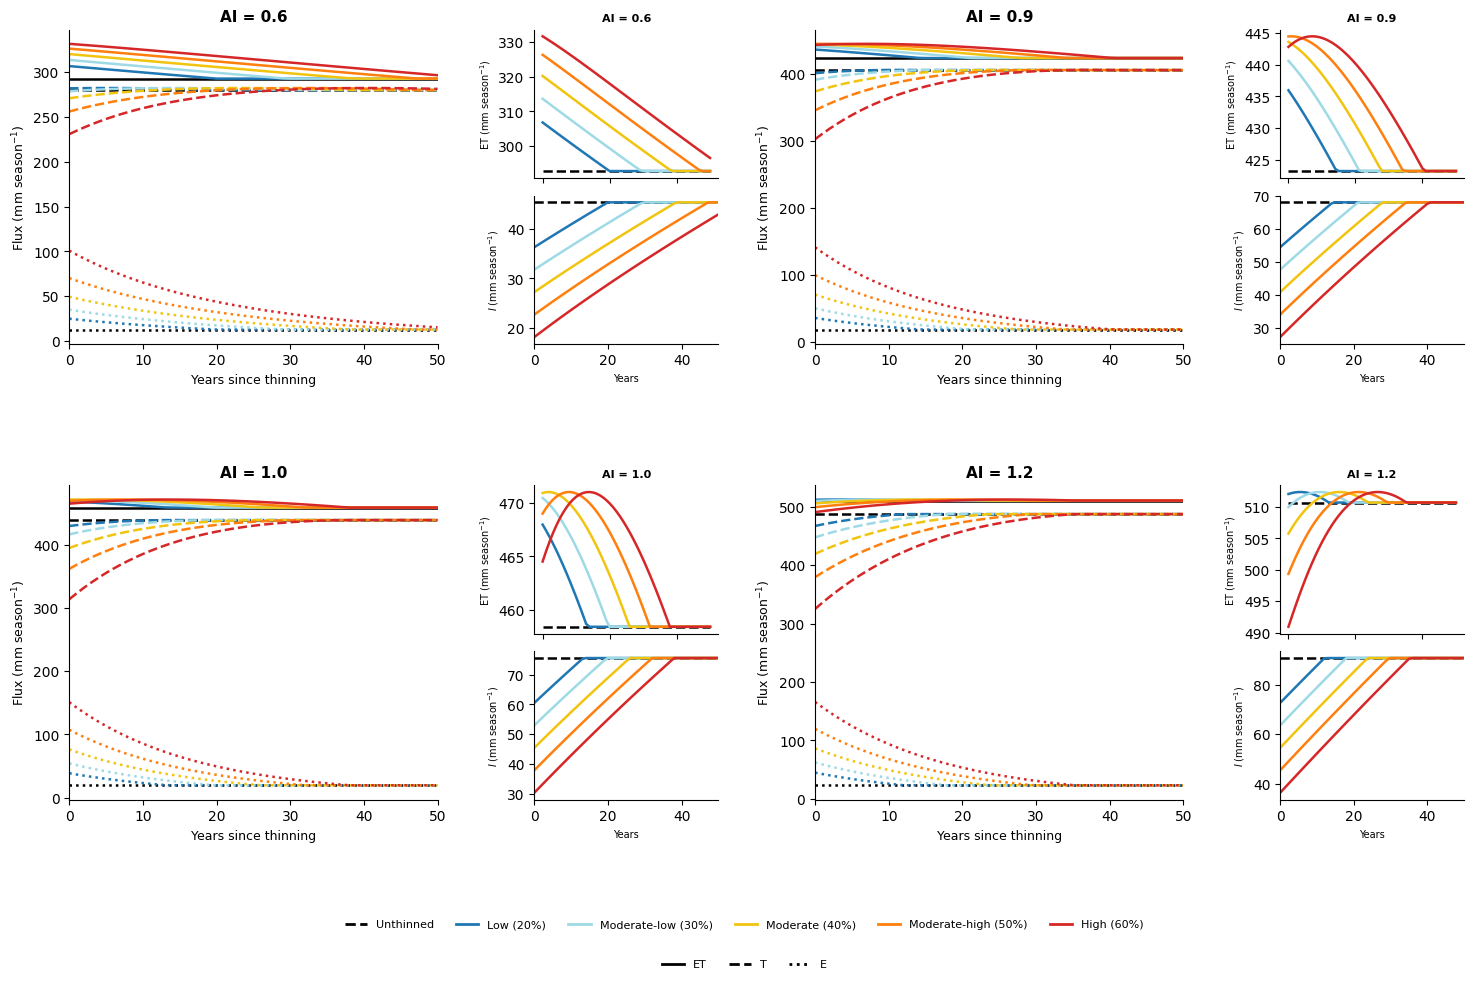

In [ ]:
%matplotlib inline

fig1 = plt.figure(figsize=(18, 10))
gs1  = GridSpec(2, 4, figure=fig1,
                width_ratios=[2, 1, 2, 1],
                hspace=0.45, wspace=0.35)

for i, (ai_label, AI) in enumerate(AI_SCENARIOS.items()):
    row = i // 2
    col = (i % 2) * 2

    ax_main = fig1.add_subplot(gs1[row, col])
    igs     = GridSpecFromSubplotSpec(2, 1,
                                      subplot_spec=gs1[row, col + 1],
                                      hspace=0.12)
    ax_et = fig1.add_subplot(igs[0])
    ax_I  = fig1.add_subplot(igs[1])

    d_ref = all_results[ai_label]['Unthinned']

    for scenario, color in COLORS.items():
        d  = all_results[ai_label][scenario]
        ls = '--' if scenario == 'Unthinned' else '-'

        
        ax_main.plot(d['year'], d['ET'], color=color, ls='-',  lw=1.8)
        ax_main.plot(d['year'], d['T'],  color=color, ls='--', lw=1.8)
        ax_main.plot(d['year'], d['E'],  color=color, ls=':',  lw=1.8)

        
        ax_et.plot(d['year'], d['ET'], color=color, ls=ls, lw=1.8)


        ax_I.plot(d['year'], d['I'], color=color, ls=ls, lw=1.8)

    ax_main.set_title(ai_label, fontsize=11, fontweight='bold')
    ax_main.set_ylabel(r'Flux (mm season$^{-1}$)', fontsize=9)
    ax_main.set_xlabel('Years since thinning', fontsize=9)
    ax_main.set_xlim([0, N_YEARS])
    ax_main.spines[['top', 'right']].set_visible(False)

    ax_et.set_title(ai_label, fontsize=8, fontweight='bold')
    ax_et.set_ylabel(r'ET (mm season$^{-1}$)', fontsize=7)
    ax_et.set_xticklabels([])
    ax_et.spines[['top', 'right']].set_visible(False)

    ax_I.set_ylabel(r'$I$ (mm season$^{-1}$)', fontsize=7)
    ax_I.set_xlabel('Years', fontsize=7)
    ax_I.set_xlim([0, N_YEARS])
    ax_I.spines[['top', 'right']].set_visible(False)

legend_thin = [
    Line2D([0], [0], color=c, lw=2,
           ls='--' if s == 'Unthinned' else '-', label=s)
    for s, c in COLORS.items()
]
legend_flux = [
    Line2D([0], [0], color='k', lw=2, ls='-',  label='ET'),
    Line2D([0], [0], color='k', lw=2, ls='--', label='T'),
    Line2D([0], [0], color='k', lw=2, ls=':',  label='E'),
]
fig1.legend(handles=legend_thin,
            fontsize=8, frameon=False,
            loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.03))
fig1.legend(handles=legend_flux,
            fontsize=8, frameon=False,
            loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.07))

plt.show()

Plot: p0(s)


all_mean_s range: 0.4307 – 0.6589
g_plus from param.py: 0.000600


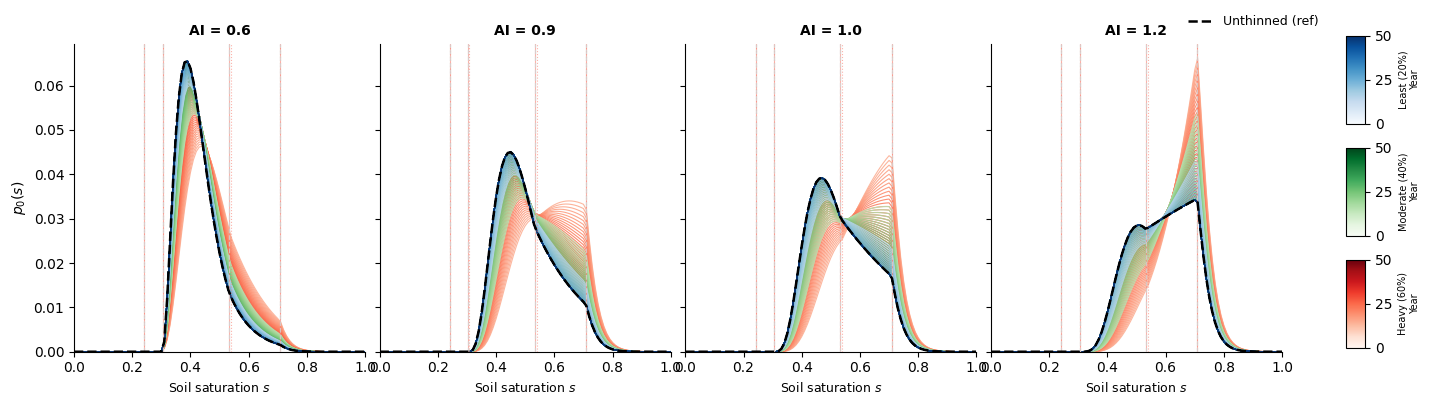

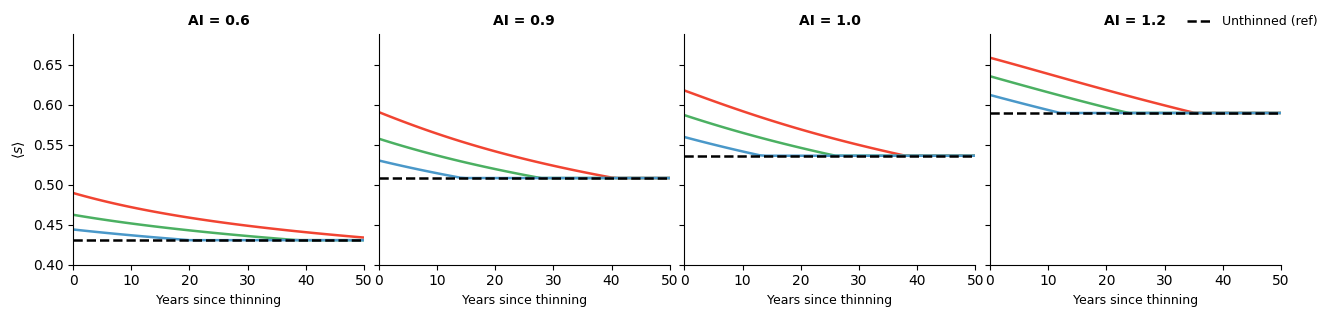

In [29]:
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize

SCENARIO_CMAPS = {
    'Low (20%)':      'Blues',
    'Moderate (40%)': 'Greens',
    'High (60%)':     'Reds',
}

SCENARIOS_TO_PLOT_ORDERED = [
    ('Heavy (60%)',    'High (60%)'),
    ('Moderate (40%)', 'Moderate (40%)'),
    ('Least (20%)',    'Low (20%)'),
]

SCENARIOS_CBAR_ORDER = [
    ('Least (20%)',    'Low (20%)'),
    ('Moderate (40%)', 'Moderate (40%)'),
    ('Heavy (60%)',    'High (60%)'),
]

N_YEARS_P0 = 50
s_plot     = np.linspace(0, 1, 101)
years_all  = np.arange(0, N_YEARS_P0 + 1)

fig_p0 = plt.figure(figsize=(16, 4))
fig_ms = plt.figure(figsize=(16, 3))

axes_p0 = [fig_p0.add_subplot(1, 4, c+1) for c in range(4)]
axes_ms = [fig_ms.add_subplot(1, 4, c+1) for c in range(4)]

all_mean_s_scalars = []

for col, (ai_label, AI) in enumerate(AI_SCENARIOS.items()):
    ax_p  = axes_p0[col]
    ax_ms = axes_ms[col]
    rf_lambda = AI * EO / RF_ALPHA

    params_ref = get_baseline_params(soil_i=3)
    params_ref.update(Eo=EO, rf_alpha=RF_ALPHA, rf_lambda=rf_lambda, LAI=LAI_REF)
    sm_ref = SM_C_H([params_ref[p] for p in full_param_name_list],
                    f_wilt=0.05, f_star=0.95, constraints=False)
    ax_p.plot(s_plot, sm_ref.p0, color='black', lw=1.8, ls='--', zorder=10)

    for sv in [sm_ref.s_h, sm_ref.s_wilt, sm_ref.s_star, sm_ref.s_fc]:
        ax_p.axvline(sv, color='lightgray', lw=0.9, ls='--', alpha=0.8, zorder=9)

    s_int      = np.linspace(0, 1, len(sm_ref.p0))

    #mean s_ref
    mean_s_ref = float(np.sum(s_int * sm_ref.p0))


    all_mean_s_scalars.append(mean_s_ref)
    ax_ms.axhline(mean_s_ref, color='black', lw=1.8, ls='--', zorder=10)

    for row_label, scenario in SCENARIOS_TO_PLOT_ORDERED:
        d          = all_results[ai_label][scenario]
        cmap_s     = plt.colormaps[SCENARIO_CMAPS[scenario]]
        line_color = cmap_s(0.6)
        colors_yr  = [cmap_s(0.3 + 0.7 * k / (len(years_all) - 1))
                      for k in range(len(years_all))]

        mean_s_list = []

        for k, yr in enumerate(years_all):
            row_d = d[d['year'] == yr]
            if row_d.empty:
                mean_s_list.append(np.nan)
                continue
            LAI_yr = row_d['LAI'].values[0]

            params = get_baseline_params(soil_i=3)
            params.update(Eo=EO, rf_alpha=RF_ALPHA, rf_lambda=rf_lambda, LAI=LAI_yr)
            sm = SM_C_H([params[p] for p in full_param_name_list],
                        f_wilt=0.05, f_star=0.95, constraints=False)

            ax_p.plot(s_plot, sm.p0, color=colors_yr[k], lw=0.8, alpha=0.85)

            #mean s 
            s_int = np.linspace(0, 1, len(sm.p0))
            ms    = float(np.sum(s_int * sm.p0))
            mean_s_list.append(ms)
            
            all_mean_s_scalars.append(ms)

        ax_ms.plot(years_all, mean_s_list, color=line_color, lw=1.8)

        if scenario == 'High (60%)':
            for yr_mark, ls_mark in [(0, ':'), (N_YEARS_P0, '-')]:
                row_d = d[d['year'] == yr_mark]
                if row_d.empty:
                    continue
                LAI_yr = row_d['LAI'].values[0]
                params = get_baseline_params(soil_i=3)
                params.update(Eo=EO, rf_alpha=RF_ALPHA,
                              rf_lambda=rf_lambda, LAI=LAI_yr)
                sm_mark = SM_C_H([params[p] for p in full_param_name_list],
                                 f_wilt=0.05, f_star=0.95, constraints=False)
                for sv in [sm_mark.s_h,   sm_mark.s_wilt,
                           sm_mark.s_star, sm_mark.s_fc]:
                    ax_p.axvline(sv, color='salmon', lw=0.8,
                                 ls=ls_mark, alpha=0.6, zorder=5)

    for ax in [ax_p, ax_ms]:
        ax.set_title(ai_label, fontsize=10, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)

    ax_p.set_xlim([0, 1])
    ax_p.set_xlabel('Soil saturation $s$', fontsize=9)

    ax_ms.set_xlim([0, N_YEARS_P0])
    ax_ms.set_xlabel('Years since thinning', fontsize=9)

axes_p0[0].set_ylabel('$p_0(s)$', fontsize=10)
axes_ms[0].set_ylabel(r'$\langle s \rangle$', fontsize=10)

p0_max = max(ax.get_ylim()[1] for ax in axes_p0)
for ax in axes_p0:
    ax.set_ylim([0, p0_max])

print(f"\nall_mean_s range: {min(all_mean_s_scalars):.4f} – {max(all_mean_s_scalars):.4f}")
print(f"g_plus from param.py: {get_baseline_params()['g_plus']:.6f}")

ms_min = min(v for v in all_mean_s_scalars if np.isfinite(v))
ms_max = max(v for v in all_mean_s_scalars if np.isfinite(v))

y_bottom = 0.40
y_top    = ms_max + 0.03

for ax in axes_ms:
    ax.set_ylim([y_bottom, y_top])
    ax.set_yticks(np.arange(0.40, y_top + 0.001, 0.05))

for ax in axes_p0[1:]:
    ax.set_ylabel('')
    ax.tick_params(labelleft=False)

for ax in axes_ms[1:]:
    ax.set_ylabel('')
    ax.tick_params(labelleft=False)

for i, (row_label, scenario) in enumerate(SCENARIOS_CBAR_ORDER):
    cmap_s = plt.colormaps[SCENARIO_CMAPS[scenario]]
    cax    = fig_p0.add_axes([0.92, 0.68 - i * 0.28, 0.012, 0.22])
    cb     = ColorbarBase(cax, cmap=cmap_s,
                          norm=Normalize(vmin=0, vmax=N_YEARS_P0),
                          orientation='vertical')
    cb.set_label(f'{row_label}\nYear', fontsize=7)
    cb.set_ticks([0, 25, 50])

for fig in [fig_p0, fig_ms]:
    fig.legend(
        handles=[Line2D([0], [0], color='black', lw=1.8, ls='--',
                        label='Unthinned (ref)')],
        loc='upper right', bbox_to_anchor=(0.91, 0.98),
        fontsize=9, frameon=False
    )

fig_p0.subplots_adjust(right=0.88, wspace=0.05)
fig_ms.subplots_adjust(right=0.88, wspace=0.05)

plt.show()

Plot: dynamics water stress + water use performance

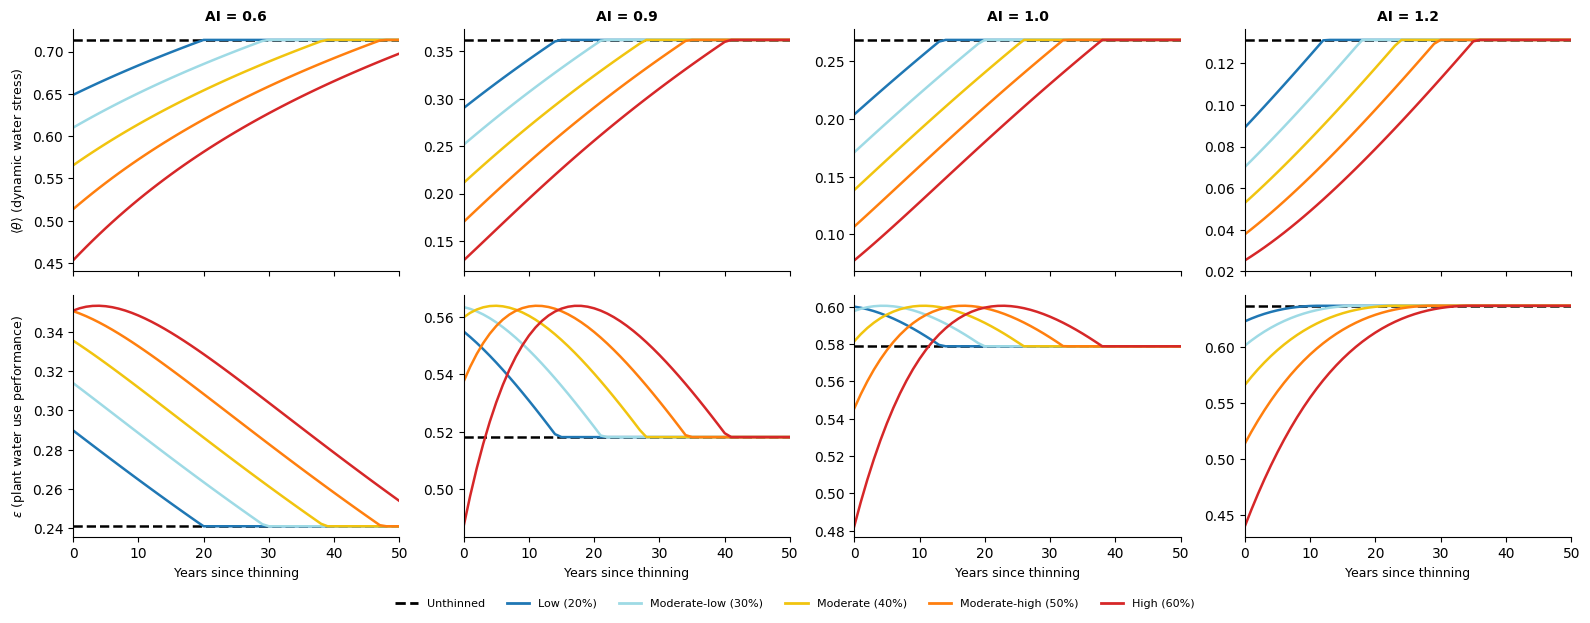

In [32]:
%matplotlib inline



METRICS = {
    r'$\langle\theta\rangle$ (dynamic water stress)': 
        lambda sm: sm.mean_dynamic_water_stress(sm.p0),
    r'$\varepsilon$ (plant water use performance)':   
        lambda sm: sm.eval_epsilon_dyn(),
}

n_metrics = len(METRICS)
fig, axes = plt.subplots(n_metrics, 4,
                         figsize=(16, 6),
                         sharey=False, sharex=True)

for col, (ai_label, AI) in enumerate(AI_SCENARIOS.items()):
    rf_lambda = AI * EO / RF_ALPHA

    for row, (metric_label, metric_fn) in enumerate(METRICS.items()):
        ax = axes[row, col]

        for scenario, color in COLORS.items():
            d  = all_results[ai_label][scenario]
            ls = '--' if scenario == 'Unthinned' else '-'

            metric_list = []
            years_plot  = []

            for yr in YEARS:
                row_d = d[d['year'] == yr]
                if row_d.empty:
                    continue
                LAI_yr = row_d['LAI'].values[0]

                params = get_baseline_params(soil_i=3)
                params.update(Eo=EO, rf_alpha=RF_ALPHA,
                              rf_lambda=rf_lambda, LAI=LAI_yr)
                sm = SM_C_H([params[p] for p in full_param_name_list],
                            f_wilt=0.05, f_star=0.95, constraints=False)

                val = metric_fn(sm)
                metric_list.append(val if np.isfinite(val) else np.nan)
                years_plot.append(yr)

            ax.plot(years_plot, metric_list, color=color, lw=1.8, ls=ls)

        if row == 0:
            ax.set_title(ai_label, fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(metric_label, fontsize=9)
        if row == n_metrics - 1:
            ax.set_xlabel('Years since thinning', fontsize=9)
        ax.set_xlim([0, N_YEARS])
        ax.spines[['top', 'right']].set_visible(False)

legend_handles = [
    Line2D([0], [0], color=c, lw=2,
           ls='--' if s == 'Unthinned' else '-', label=s)
    for s, c in COLORS.items()
]
fig.legend(handles=legend_handles, ncol=6, fontsize=8,
           frameon=False, loc='lower center', bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.show()

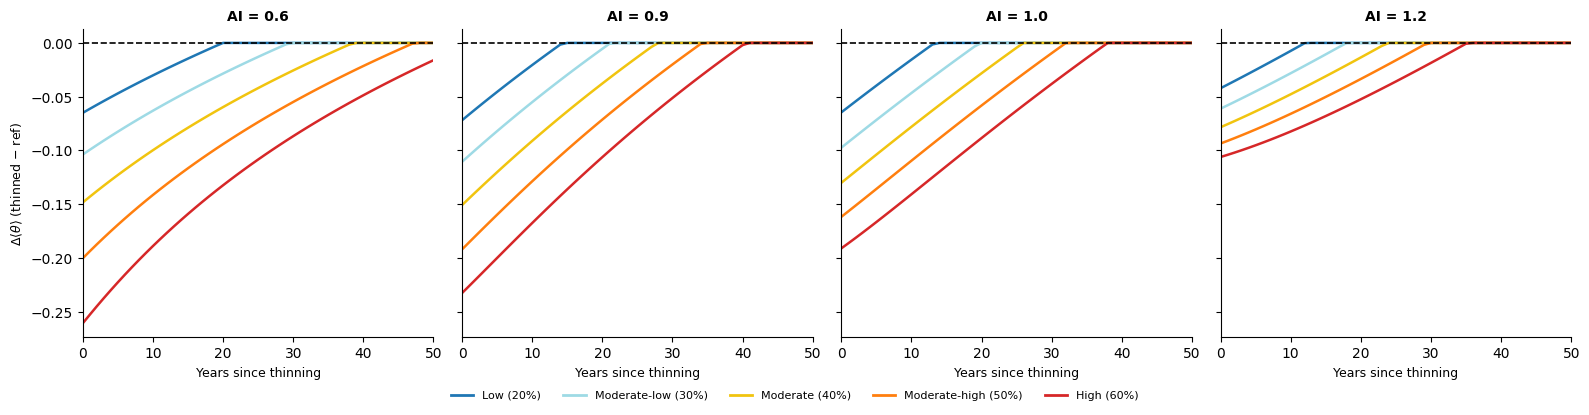

In [ ]:

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True, sharex=True)

for col, (ai_label, AI) in enumerate(AI_SCENARIOS.items()):
    rf_lambda = AI * EO / RF_ALPHA
    ax = axes[col]

 
    d_ref = all_results[ai_label]['Unthinned']
    ref_stress = {}
    for yr in YEARS:
        row_d = d_ref[d_ref['year'] == yr]
        if row_d.empty:
            continue
        LAI_yr = row_d['LAI'].values[0]
        params = get_baseline_params(soil_i=3)
        params.update(Eo=EO, rf_alpha=RF_ALPHA, rf_lambda=rf_lambda, LAI=LAI_yr)
        sm = SM_C_H([params[p] for p in full_param_name_list],
                    f_wilt=0.05, f_star=0.95, constraints=False)
        ref_stress[yr] = sm.mean_dynamic_water_stress(sm.p0)

    for scenario, color in COLORS.items():
        if scenario == 'Unthinned':
            continue
        d = all_results[ai_label][scenario]

        delta_list = []
        years_plot = []

        for yr in YEARS:
            row_d = d[d['year'] == yr]
            if row_d.empty or yr not in ref_stress:
                continue
            LAI_yr = row_d['LAI'].values[0]
            params = get_baseline_params(soil_i=3)
            params.update(Eo=EO, rf_alpha=RF_ALPHA, rf_lambda=rf_lambda, LAI=LAI_yr)
            sm = SM_C_H([params[p] for p in full_param_name_list],
                        f_wilt=0.05, f_star=0.95, constraints=False)
            val = sm.mean_dynamic_water_stress(sm.p0)
            delta_list.append(val - ref_stress[yr])
            years_plot.append(yr)

        ax.plot(years_plot, delta_list, color=color, lw=1.8)

    ax.axhline(0, color='black', lw=1.2, ls='--')
    ax.set_title(ai_label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Years since thinning', fontsize=9)
    ax.set_xlim([0, N_YEARS])
    ax.spines[['top', 'right']].set_visible(False)
    if col > 0:
        ax.tick_params(labelleft=False)

axes[0].set_ylabel(r'$\Delta\langle\theta\rangle$ (thinned $-$ ref)', fontsize=9)

# sync y
ymin = min(ax.get_ylim()[0] for ax in axes)
ymax = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim([ymin, ymax])

legend_handles = [
    Line2D([0], [0], color=c, lw=2, label=s)
    for s, c in COLORS.items() if s != 'Unthinned'
]
fig.legend(handles=legend_handles, ncol=5, fontsize=8,
           frameon=False, loc='lower center', bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.show()


In [34]:
import numpy as np

EO       = 0.0035   # m/day
RF_ALPHA = 0.01     # m
T_GS     = 180      # days
AI_SCENARIOS = {
    'AI = 0.6': 0.6,
    'AI = 0.9': 0.9,
    'AI = 1.0': 1.0,
    'AI = 1.2': 1.2,
}

print(f"{'Scenario':<12} {'rf_lambda (day⁻¹)':>20} {'rf_alpha (m)':>14} {'Mean seasonal P (mm)':>22}")
print("-" * 72)
for label, AI in AI_SCENARIOS.items():
    rf_lambda = AI * EO / RF_ALPHA
    P_seasonal = rf_lambda * RF_ALPHA * T_GS * 1000  # mm
    print(f"{label:<12} {rf_lambda:>20.4f} {RF_ALPHA:>14.4f} {P_seasonal:>22.1f}")

Scenario        rf_lambda (day⁻¹)   rf_alpha (m)   Mean seasonal P (mm)
------------------------------------------------------------------------
AI = 0.6                   0.2100         0.0100                  378.0
AI = 0.9                   0.3150         0.0100                  567.0
AI = 1.0                   0.3500         0.0100                  630.0
AI = 1.2                   0.4200         0.0100                  756.0
